# Core Supervised Learning: Preprocessing, Models & Evaluation

 Builds on Day 1's Adult dataset baseline

## Setup: reload data & reproduce Day 1's exact split
Same `random_state=42`, same stratified 80/20 split, so `X_train`/`X_test`/`y_train`/`y_test`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

In [2]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

df["class"] = (
    df["class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .map({"<=50K": 0, ">50K": 1})
)

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (39073, 14)
Testing Set : (9769, 14)


## Task 1: Preprocessing Plan & Implementation

**Numeric features (6):** age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week

**Categorical features (8):** workclass, education, marital-status, occupation, relationship, race, sex, native-country

Adult dataset from OpenML already stores missing values as NaN, so no additional replacement of '?' was required.

**Why median imputation (numeric):** capital-gain and capital-loss are highly skewed (mean=1079 vs median=0 for capital-gain), with extreme outliers (max=99,999). Mean imputation would be pulled toward these outliers and produce unrealistic fill values; median reflects the typical value and is robust to outliers. *Alternative considered:* mean imputation skipped because of the skew described above.

**Why a dedicated "Missing" category (categorical) chosen over most-frequent:**

The task allows either `most_frequent` or a `"Missing"` label for categorical imputation. Exploratory analysis of the missing `workclass` records (2,799 rows) showed they are *not* a random subset of the data:

| Metric | Missing-workclass group | Full dataset |
|---|---|---|
| hours-per-week (mean) | 31.81 | 40.42 |
| capital-gain (mean) | 502.95 | 1079.07 |
| capital-loss (mean) | 67.63 | 87.50 |

Missing-`workclass` individuals work noticeably fewer hours per week (~31.8 vs. 40.4) and have lower capital-gain/loss than the dataset average a systematic difference, not random noise. Notably, `workclass` already contains explicit `Never-worked` and `Without-pay` categories, so these NaNs likely aren't simple "unemployed" cases mislabeled as missing; they appear to represent an under-reported or distinct sub-population (e.g., irregular/part-time work) whose pattern the model should be allowed to learn separately.

Filling these with the majority class (`Private`, the most frequent category) would overwrite this signal and tell the model these individuals look like typical full-time private-sector workers, which the data does not support. A dedicated `"Missing"` category preserves this distinction as its own feature level, letting the model learn from it directly. *Alternative considered:* most-frequent imputation skipped because it would erase a measurable, systematic pattern in the missing group.

The 'Missing' category strategy was applied uniformly across all categorical features for consistency. While direct evidence for systematic missingness was only gathered for workclass, the reasoning extends reasonably to native-country given its comparable missing-value count (857) relative to existing rare categories in the column, the addition does not meaningfully worsen the pre-existing sparse-category instability already present in this feature.

A direct overlap check confirmed that missing `workclass` and `occupation` values come from the same individuals: **100% of `workclass` NaNs (2,799 of 2,799) are also `occupation` NaNs**, with only 10 additional occupation-only NaNs. This is not coincidental, it reflects the survey structure, where someone unable to report a broad employment category is structurally unable to report a specific job title either. This confirms the "Missing" category is the correct choice for both features, since most-frequent imputation would fabricate employment details for the same underrepresented group twice.

**Why OneHotEncoder:** categorical features here are nominal (no inherent order,  e.g., occupation categories aren't ranked), so one-hot encoding avoids implying a false ordinal relationship that label/ordinal encoding would introduce. `handle_unknown="ignore"` protects against unseen categories appearing at test time.

In [3]:
# Check overlap between missing workclass and missing occupation
missing_workclass = df["workclass"].isna()
missing_occupation = df["occupation"].isna()

both_missing = (missing_workclass & missing_occupation).sum()
only_workclass_missing = (missing_workclass & ~missing_occupation).sum()
only_occupation_missing = (~missing_workclass & missing_occupation).sum()

print(f"Missing workclass only        : {only_workclass_missing}")
print(f"Missing occupation only       : {only_occupation_missing}")
print(f"Missing BOTH workclass & occ  : {both_missing}")
print(f"Total missing workclass       : {missing_workclass.sum()}")
print(f"Total missing occupation      : {missing_occupation.sum()}")
print(f"Overlap %  (of workclass NaNs): {both_missing / missing_workclass.sum() * 100:.2f}%")

Missing workclass only        : 0
Missing occupation only       : 10
Missing BOTH workclass & occ  : 2799
Total missing workclass       : 2799
Total missing occupation      : 2809
Overlap %  (of workclass NaNs): 100.00%


A follow up check confirmed that missing `workclass` and `occupation` values overlap almost perfectly: **100% of workclass NaNs are also occupation NaNs** (2,799 out of 2,799), with only 10 additional occupation-only NaNs. This is not coincidental — it reflects the survey structure, where someone who doesn't report a broad employment category is structurally unable to report a specific job title. This confirms that a dedicated "Missing" category is the correct choice for both features, since most-frequent imputation would misrepresent the same group of individuals twice (once in workclass, once in occupation) with fabricated employment details.

In [4]:
numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "education", "marital-status", "occupation",
                         "relationship", "race", "sex", "native-country"]

# Numeric pipeline: median imputation -> standard scaling
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: dedicated "Missing" category -> one-hot encoding
#
# Chosen over most_frequent imputation: exploratory analysis showed missing
# `workclass` records average ~31.8 hours/week vs. ~40.4 for the full dataset
# (and lower capital-gain/loss too) - a systematic difference, not random
# missingness. `workclass` already has explicit "Never-worked"/"Without-pay"
# categories, so filling NaNs with the majority class ("Private") would
# incorrectly tell the model these individuals are typical full-time
# private-sector workers. A dedicated "Missing" category preserves this
# signal instead of erasing it.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Task 2: Train Two Supervised Models (in Pipelines)
Fit on `X_train`/`y_train` only and hold-out test set is not touched here.

In [5]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, solver="liblinear", max_iter=1000))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

print("Both models fitted on training data.")

Both models fitted on training data.


## Task 3: Evaluate on Hold-Out Test (Multiple Metrics)

In [6]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba),
        "PR AUC": average_precision_score(y_true, y_proba)
    }

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

logreg_results = evaluate_model("Logistic Regression", y_test, y_pred_logreg, y_proba_logreg)
tree_results = evaluate_model("Decision Tree", y_test, y_pred_tree, y_proba_tree)

# Day 1 baselines (recomputed here for a single combined table)
day1_majority = {"Model": "Day1: Majority Baseline", "Accuracy": 0.760672, "Precision": 0.0,
                  "Recall": 0.0, "F1 Score": 0.0, "ROC AUC": 0.5, "PR AUC": 0.239328}
day1_rule = {"Model": "Day1: Rule Baseline (capital-gain>0)", "Accuracy": 0.78227, "Precision": 0.625446,
             "Recall": 0.224979, "F1 Score": 0.330922, "ROC AUC": 0.591294, "PR AUC": 0.326197}

comparison = pd.DataFrame([day1_majority, day1_rule, logreg_results, tree_results]).set_index("Model")
comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Model,,,,,,
Day1: Majority Baseline,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
Day1: Rule Baseline (capital-gain>0),0.782270,0.625446,0.224979,0.330922,0.591294,0.326197
Logistic Regression,0.854233,0.742827,0.597947,0.662559,0.905771,0.767138
Decision Tree,0.818610,0.618509,0.631737,0.625053,0.754571,0.478871


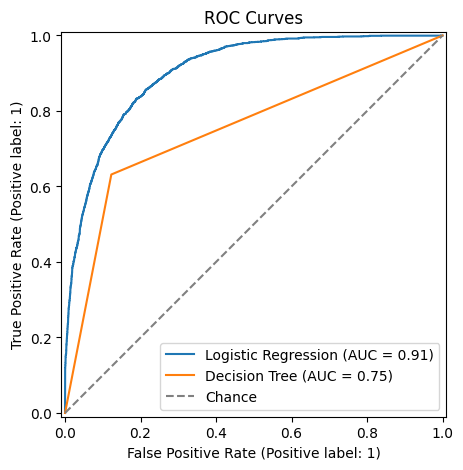

In [7]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name="Decision Tree", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves")
plt.legend()
plt.show()

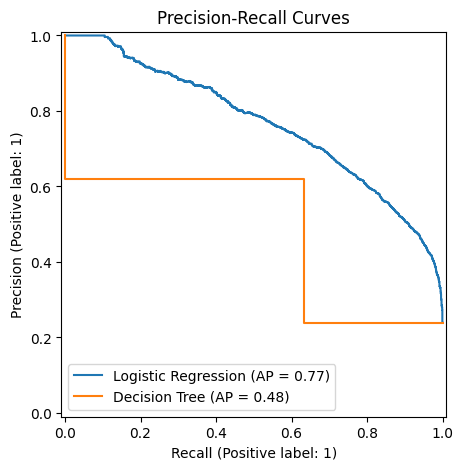

In [8]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_logreg, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_tree, name="Decision Tree", ax=ax)
ax.set_title("Precision-Recall Curves")
plt.legend()
plt.show()

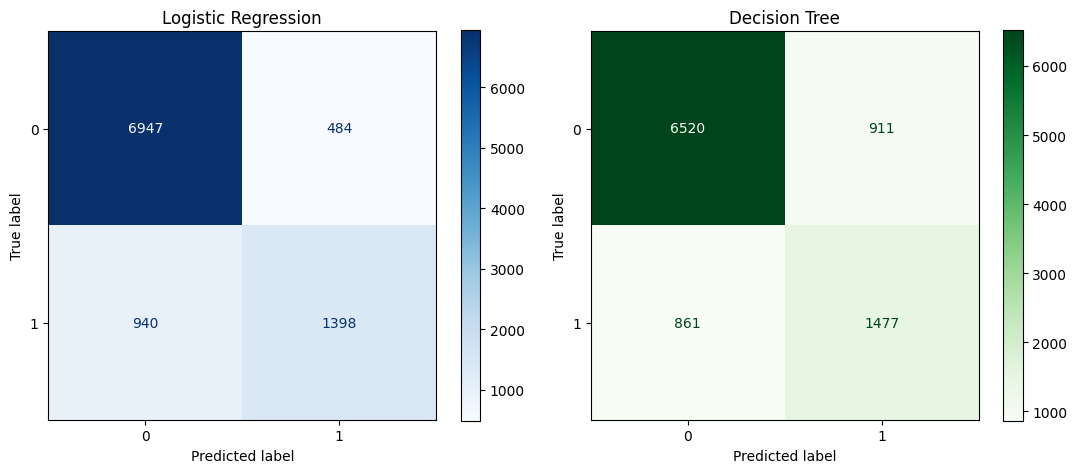

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, cmap="Greens", ax=axes[1])
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

**Which error type is more common?**

 False negatives dominate for both models, most notably for Logistic Regression (940 FN vs. 484 FP  nearly double). This means both models are relatively conservative about predicting the positive (>$50K) class, missing some genuine high earners rather than over-predicting. Given the business objective of Precision@top-k (minimizing wasted outreach), this trade-off is favorable, Logistic Regression in particular achieves a low false-positive count (484), directly supporting high precision, at the cost of a somewhat lower recall (0.5979). Decision Tree balances the two error types more evenly (911 FP vs. 861 FN), reflecting its comparatively higher recall (0.6317) but lower precision.

## Task 4: Interpretability Check

### Logistic Regression coefficients

In [10]:
feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

print("Top 10 POSITIVE coefficients (push prediction toward >50K):")
display(coef_df.head(10))

print("\nTop 10 NEGATIVE coefficients (push prediction toward <=50K):")
display(coef_df.tail(10).sort_values("Coefficient"))

Top 10 POSITIVE coefficients (push prediction toward >50K):


,Feature,Coefficient
3,num__capital-gain,2.264715
33,cat__marital-status_Married-civ-spouse,1.544158
32,cat__marital-status_Married-AF-spouse,1.331776
75,cat__native-country_France,0.925484
86,cat__native-country_Ireland,0.920974
66,cat__native-country_Cambodia,0.829516
41,cat__occupation_Exec-managerial,0.823453
74,cat__native-country_England,0.766407
58,cat__relationship_Wife,0.742558
2,num__education-num,0.718999



Top 10 NEGATIVE coefficients (push prediction toward <=50K):


,Feature,Coefficient
47,cat__occupation_Priv-house-serv,-1.463816
69,cat__native-country_Columbia,-1.440686
35,cat__marital-status_Never-married,-1.287809
64,cat__sex_Female,-1.031226
101,cat__native-country_South,-0.940255
104,cat__native-country_Trinadad&Tobago,-0.940028
55,cat__relationship_Other-relative,-0.928321
42,cat__occupation_Farming-fishing,-0.922528
71,cat__native-country_Dominican-Republic,-0.907902
46,cat__occupation_Other-service,-0.863078


**Interpretation:**

The top positive coefficients are dominated by intuitive, expected features  capital-gain (2.26), being married (1.54), executive/managerial occupation (0.82), and education-num (0.72) all align with real-world income patterns. However, four native-country categories (France, Ireland, Cambodia, England) also appear in the top 10, despite representing very small subgroups in the dataset (28-127 individuals each). This likely reflects instability from small sample sizes rather than genuine predictive signal, and is a caveat worth noting when interpreting coefficient magnitude as "importance"  coefficients for rare categories can be inflated by limited data.

The top negative coefficients are dominated by expected low-wage occupations (Priv-house-serv, Farming-fishing, Other-service) and Never-married status  consistent with real-world income patterns. As with the positive coefficients, several native-country categories (Columbia, South, Trinadad&Tobago, Dominican-Republic) appear despite very small sample sizes, again suggesting instability rather than robust signal.

One finding warrants explicit attention: `sex_Female` has a strongly negative coefficient (-1.03), meaning the model associates being female with lower predicted income independent of other features. This reflects a real pattern present in the 1994 Census data (a known historical gender income gap) rather than an error in the model itself  but it is a fairness consideration worth flagging, since a model trained on this pattern would reproduce that gap in its predictions if deployed for any real decision-making context.

### Decision Tree

In [11]:
train_score = tree_pipeline.score(X_train, y_train)
test_score = tree_pipeline.score(X_test, y_test)
tree_depth = tree_pipeline.named_steps["classifier"].get_depth()

print(f"Tree depth: {tree_depth}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Gap (train - test): {train_score - test_score:.4f}")

Tree depth: 68
Train accuracy: 0.9999
Test accuracy:  0.8186
Gap (train - test): 0.1813


In [12]:
tree_rules = export_text(
    tree_pipeline.named_steps["classifier"],
    feature_names=list(feature_names),
    max_depth=2  # top 3 levels of splits
)
print(tree_rules)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 0.94
|   |   |   |--- truncated branch of depth 25
|   |   |--- num__education-num >  0.94
|   |   |   |--- truncated branch of depth 29
|   |--- num__capital-gain >  0.82
|   |   |--- num__age <= -1.32
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.32
|   |   |   |--- truncated branch of depth 5
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.55
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 66
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- truncated branch of depth 8
|   |--- num__education-num >  0.55
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 48
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- truncated branch of depth 6



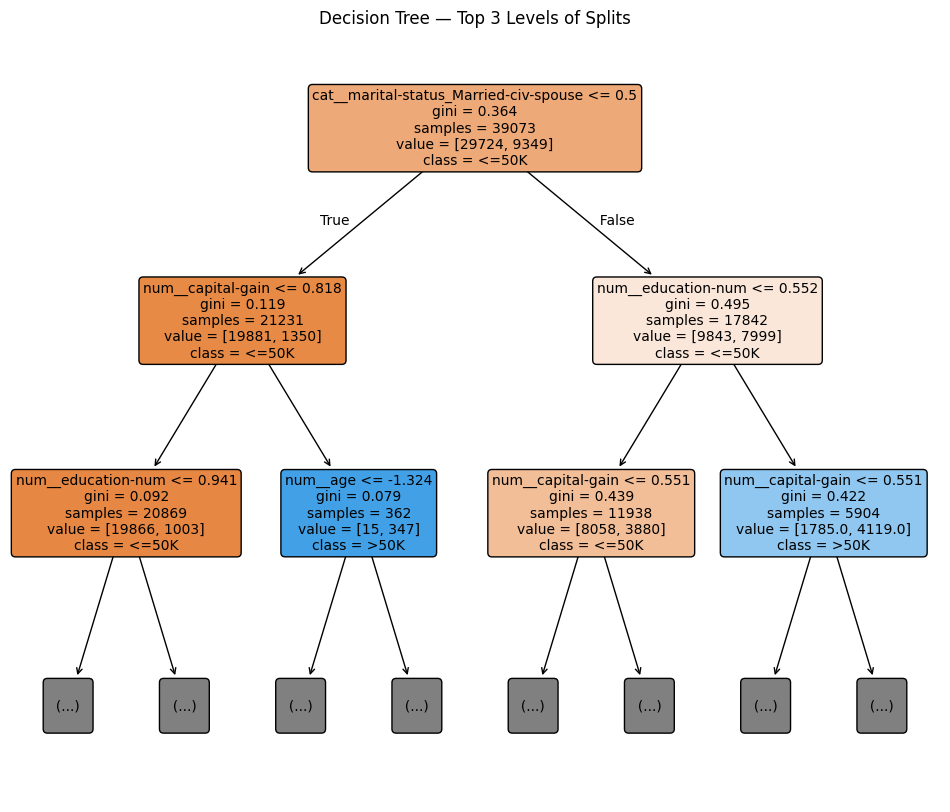

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 10))
plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=list(feature_names),
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=2,        # top 3 levels only (same as your text version)
    fontsize=10
)
plt.title("Decision Tree — Top 3 Levels of Splits")
plt.show()

In [14]:
logreg_train_score = logreg_pipeline.score(X_train, y_train)
logreg_test_score = logreg_pipeline.score(X_test, y_test)

print(f"LogReg Train accuracy: {logreg_train_score:.4f}")
print(f"LogReg Test accuracy:  {logreg_test_score:.4f}")
print(f"Gap (train - test): {logreg_train_score - logreg_test_score:.4f}")

LogReg Train accuracy: 0.8535
LogReg Test accuracy:  0.8542
Gap (train - test): -0.0007


Overfitting check: the unconstrained Decision Tree grew to depth 68, achieving 99.99% train accuracy but only 81.86% test accuracy  an 18-point gap that clearly indicates severe overfitting. The tree has memorized training examples rather than learning generalizable patterns.

Do the splits make sense? Yes, the top split (marital-status = Married-civ-spouse) aligns with real-world income patterns (married individuals often have combined household income or more stable careers), and subsequent splits on capital-gain and education-num reflect the same features identified as important in the Day 1 error analysis. The tree's logic is sound; its depth/complexity is the problem.

## Task 5: Write-Up & Model Selection for Day 3

Based on hold-out test set performance, Logistic Regression will be developed further as the primary candidate for Day 3. It outperforms the Decision Tree on nearly every metric  accuracy (0.8542 vs. 0.8186), precision (0.7428 vs. 0.6185), F1 score (0.6626 vs. 0.6251), and especially ROC AUC (0.9058 vs. 0.7546)  while showing virtually no overfitting (an absolute train–test accuracy difference of only 0.0007, indicating virtually identical performance on both datasets.). The Decision Tree, in contrast, grew unconstrained to a depth of 68 and reached 99.99% train accuracy but only 81.86% test accuracy,  an 18-point gap that confirms severe overfitting; its apparent complexity does not translate into better generalization. Given the business objective of maximizing Percision(Precision@top-k) for cost-efficient marketing outreach, Logistic Regression's higher precision and stability make it the stronger and more trustworthy candidate. It also offers directly interpretable coefficients, which is valuable for explaining predictions to non-technical stakeholders.

The Decision Tree is not being discarded entirely, however  its top splits (marital-status, capital-gain, education-num) matched real-world intuition and the patterns identified in the Day 1 error analysis, suggesting the underlying logic is sound even though the current unpruned tree is too complex. It will be revisited on Day 3 with depth constraints (max_depth, min_samples_leaf) to test whether a shallower, regularized tree can close the generalization gap while still capturing the nonlinear feature interactions that Logistic Regression's linear boundary cannot.

Reusable preprocessing pipeline: the preprocessor object (a ColumnTransformer combining median-imputation + scaling for numeric features, and "Missing"-category imputation + one-hot encoding for categorical features) is saved for direct reuse in Day 3. The same preprocessing pipeline can be reused with any compatible scikit-learn estimator, ensuring consistent preprocessing and preventing data leakage across experiments.

new_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", <new_model>)
])

Preprocessing changes to test tomorrow:

Prune the Decision Tree (max_depth, min_samples_leaf) to reduce overfitting while retaining its nonlinear splitting logic.
Log-transform capital-gain and capital-loss before scaling, given their extreme right-skew (mean ≫ median, max = 99,999).
Evaluate whether the "Missing"-category choice for categorical imputation (adopted over most_frequent based on the workclass hours-per-week analysis) measurably improves model performance compared to the most-frequent baseline, via a controlled comparison.

In [16]:
import joblib

# Save the preprocessing pipeline alone, for reuse with any new model on Day 3
joblib.dump(preprocessor, "preprocessor.pkl")

# Save the two full trained pipelines (preprocessing + model) too,
# so they can be reloaded without retraining
joblib.dump(logreg_pipeline, "logreg_full_pipeline.pkl")
joblib.dump(tree_pipeline, "tree_full_pipeline.pkl")

print("Saved: preprocessor.pkl, logreg_full_pipeline.pkl, tree_full_pipeline.pkl")

# Download to local machine (colab)
# from google.colab import files
# files.download("preprocessor.pkl")
# files.download("logreg_full_pipeline.pkl")
# files.download("tree_full_pipeline.pkl")

Saved: preprocessor.pkl, logreg_full_pipeline.pkl, tree_full_pipeline.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>